In [32]:
import polars
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np

In [15]:
sample_df = polars.read_csv("./samples.tsv", separator="\t")
print("Total number of samples:", sample_df.height)
sample_df = sample_df.filter(polars.col("fmr1_depth") > 0)
print("Number of samples with FMR1 depth > 0:", sample_df.height)

Total number of samples: 48
Number of samples with FMR1 depth > 0: 40


      Sex  len
0  female   11
1    male   14


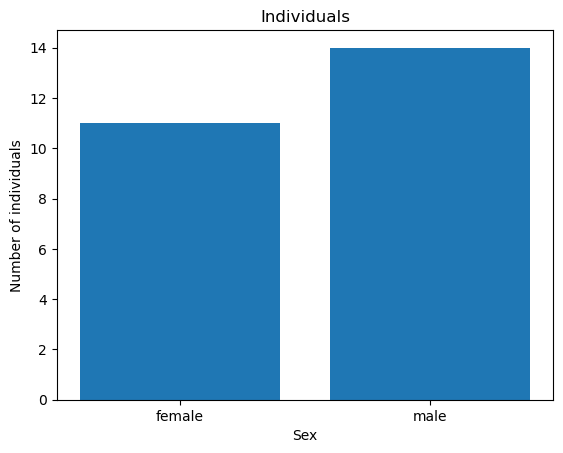

In [21]:
counts = (sample_df.select(["Individual", "Sex"]).unique().group_by("Sex").len().sort("Sex"))
# Convert to pandas for easy plotting with matplotlib
pdf = counts.to_pandas()
print(pdf)


# ---- bar plot ----
plt.figure()
plt.bar(pdf["Sex"], pdf["len"])    # categories vs counts
plt.xlabel("Sex")
plt.ylabel("Number of individuals")
plt.title("Individuals")

ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()

/var/folders/l6/gw6wswn15lg9cy154l9_8jfr0000gp/T/ipykernel_78667/3394141132.py:6: DeprecationWarning: The argument `columns` for `DataFrame.pivot` is deprecated. It has been renamed to `on`.
  .pivot(


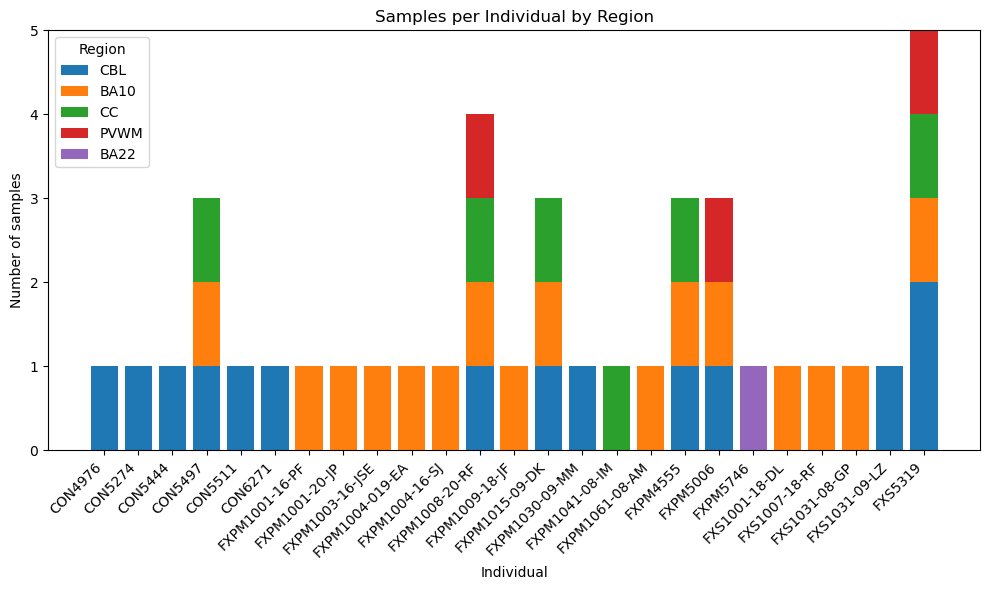

In [ ]:
counts = sample_df.select(["Individual", "Region", "Sex"]).group_by(["Individual", "Region", "Sex"]).agg(polars.len().alias("count"))

wide = (
    counts
    .pivot(
        values="count",
        index=["Individual", "Sex"],
        columns="Region",
        aggregate_function="first"
    )
    .fill_null(0)
    .sort(["Sex", "Individual"])
)

individuals = wide["Individual"].to_list()
regions = wide.columns[1:]  # exclude Individual column

x = np.arange(len(individuals))
bottom = np.zeros(len(individuals))

plt.figure(figsize=(10, 6))

for region in regions:
    values = wide[region].to_numpy()
    plt.bar(x, values, bottom=bottom, label=region)
    bottom += values

plt.xticks(x, individuals, rotation=45, ha="right")
plt.xlabel("Individual")
plt.ylabel("Number of samples")
plt.title("Samples per Individual by Region")
plt.legend(title="Region")
plt.tight_layout()
plt.show()